In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, roc_auc_score
)

sns.set_theme(style='whitegrid')

# ── Chargement ───────────────────────────────────────────────────────────────
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test  = pd.read_csv('y_test.csv').values.ravel()

X_train_bow   = sp.load_npz('X_train_bow.npz')
X_test_bow    = sp.load_npz('X_test_bow.npz')
X_train_tfidf = sp.load_npz('X_train_tfidf.npz')
X_test_tfidf  = sp.load_npz('X_test_tfidf.npz')

print('Chargement OK')
print(f'y_train : {y_train.shape}, spam={y_train.mean():.1%}')

Chargement OK
y_train : (4457,), spam=13.4%


In [2]:
def evaluate(model, X_test, y_test, model_name='', vectorizer_name='') -> dict:
    """Évalue un modèle et retourne les métriques principales."""
    y_pred = model.predict(X_test)

    if hasattr(model, 'predict_proba'):
        y_scores = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_scores = model.decision_function(X_test)
    else:
        y_scores = y_pred

    metrics = {
        'model':      model_name,
        'vectorizer': vectorizer_name,
        'accuracy':   accuracy_score(y_test, y_pred),
        'precision':  precision_score(y_test, y_pred),
        'recall':     recall_score(y_test, y_pred),
        'f1':         f1_score(y_test, y_pred),
        'roc_auc':    roc_auc_score(y_test, y_scores),
    }
    return metrics


def plot_confusion_matrix(model, X_test, y_test, title=''):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham', 'Spam'],
                yticklabels=['Ham', 'Spam'], ax=ax)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')
    ax.set_title(title or 'Matrice de confusion')
    plt.tight_layout()
    plt.show()
    # Analyse des erreurs
    tn, fp, fn, tp = cm.ravel()
    print(f'  Vrais Positifs (spam détecté)  : {tp}')
    print(f'  Vrais Négatifs (ham correct)   : {tn}')
    print(f'  Faux Positifs (ham → spam)     : {fp}  ← emails légitimes bloqués')
    print(f'  Faux Négatifs (spam → ham)     : {fn}  ← spam non détecté')

Naive Bayes

=== Naive Bayes + BoW ===
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.94      0.91      0.92       149

    accuracy                           0.98      1115
   macro avg       0.96      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



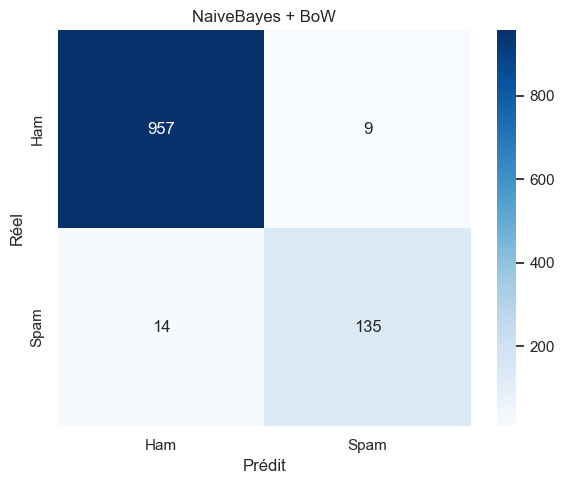

  Vrais Positifs (spam détecté)  : 135
  Vrais Négatifs (ham correct)   : 957
  Faux Positifs (ham → spam)     : 9  ← emails légitimes bloqués
  Faux Négatifs (spam → ham)     : 14  ← spam non détecté


In [3]:
# ── MultinomialNB sur BoW ────────────────────────────────────────────────────
nb_bow = MultinomialNB(alpha=1.0)  
nb_bow.fit(X_train_bow, y_train)

print('=== Naive Bayes + BoW ===')
print(classification_report(y_test, nb_bow.predict(X_test_bow), target_names=['Ham', 'Spam']))
plot_confusion_matrix(nb_bow, X_test_bow, y_test, 'NaiveBayes + BoW')


=== Naive Bayes + TF-IDF ===
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.98      0.85      0.91       149

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



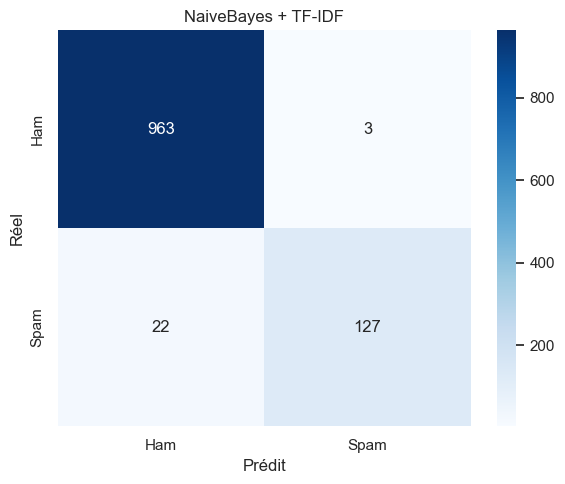

  Vrais Positifs (spam détecté)  : 127
  Vrais Négatifs (ham correct)   : 963
  Faux Positifs (ham → spam)     : 3  ← emails légitimes bloqués
  Faux Négatifs (spam → ham)     : 22  ← spam non détecté


In [6]:
# ── MultinomialNB sur TF-IDF ─────────────────────────────────────────────────
nb_tfidf = MultinomialNB(alpha=0.1)
nb_tfidf.fit(X_train_tfidf, y_train)

print('=== Naive Bayes + TF-IDF ===')
print(classification_report(y_test, nb_tfidf.predict(X_test_tfidf), target_names=['Ham', 'Spam']))
plot_confusion_matrix(nb_tfidf, X_test_tfidf, y_test, 'NaiveBayes + TF-IDF')

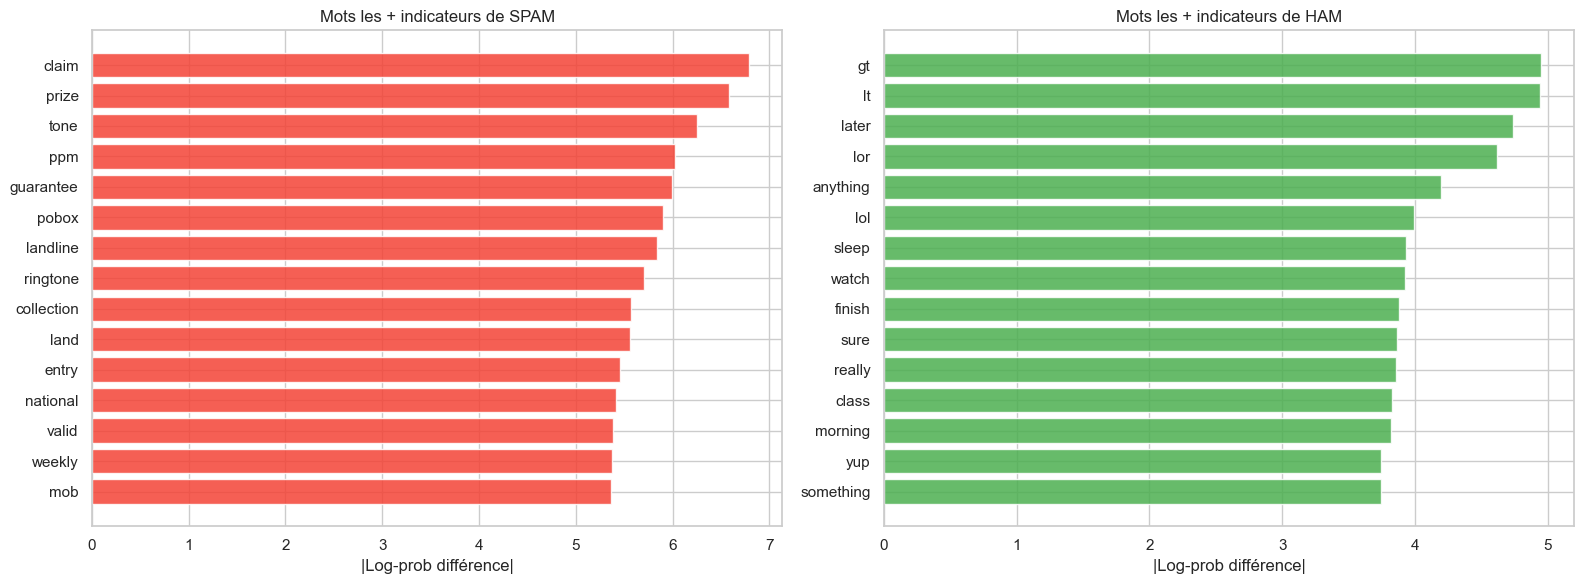

In [7]:
# ── Interprétabilité : mots les plus discriminants ──────────────────────────
with open('vectorizers.pkl', 'rb') as f:
    vecs = pickle.load(f)
tfidf_vec = vecs['tfidf']

feature_names = tfidf_vec.get_feature_names_out()
log_prob_diff = nb_tfidf.feature_log_prob_[1] - nb_tfidf.feature_log_prob_[0]
top_spam = log_prob_diff.argsort()[-15:][::-1]
top_ham  = log_prob_diff.argsort()[:15]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, indices, title, color in [
    (axes[0], top_spam, 'Mots les + indicateurs de SPAM', '#F44336'),
    (axes[1], top_ham,  'Mots les + indicateurs de HAM',  '#4CAF50')
]:
    words  = feature_names[indices]
    scores = log_prob_diff[indices]
    ax.barh(words[::-1], np.abs(scores[::-1]), color=color, alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('|Log-prob différence|')
plt.tight_layout()
plt.show()

SVM

=== SVM (LinearSVC) + TF-IDF ===
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.99      0.90      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.97      1115
weighted avg       0.98      0.98      0.98      1115



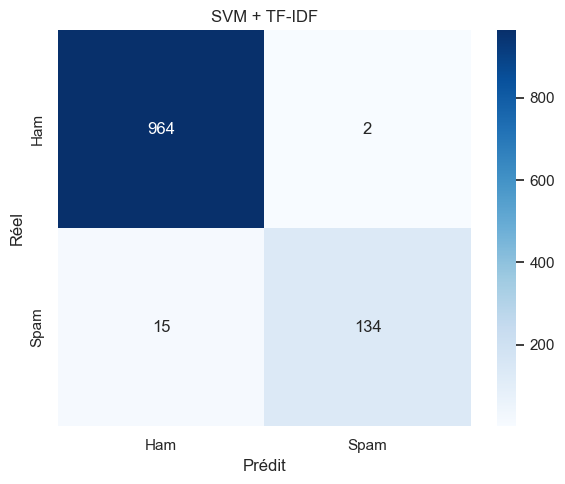

  Vrais Positifs (spam détecté)  : 134
  Vrais Négatifs (ham correct)   : 964
  Faux Positifs (ham → spam)     : 2  ← emails légitimes bloqués
  Faux Négatifs (spam → ham)     : 15  ← spam non détecté


In [8]:
# ── LinearSVC sur TF-IDF ─────────────────────────────────────────────────────
svm_tfidf = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_tfidf.fit(X_train_tfidf, y_train)

print('=== SVM (LinearSVC) + TF-IDF ===')
print(classification_report(y_test, svm_tfidf.predict(X_test_tfidf), target_names=['Ham', 'Spam']))
plot_confusion_matrix(svm_tfidf, X_test_tfidf, y_test, 'SVM + TF-IDF')

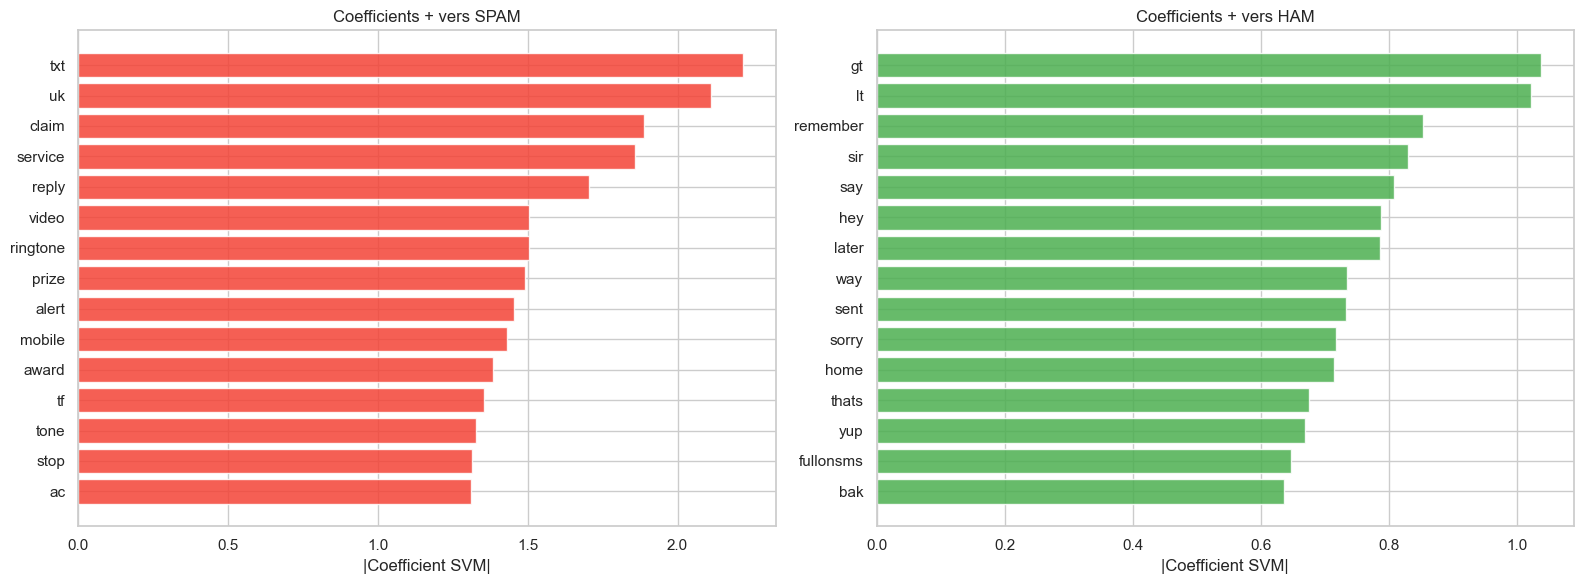

In [9]:
# ── Visualisation des coefficients SVM ──────────────────────────────────────
coef = svm_tfidf.coef_[0]
top_spam_svm = coef.argsort()[-15:][::-1]
top_ham_svm  = coef.argsort()[:15]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, indices, title, color in [
    (axes[0], top_spam_svm, 'Coefficients + vers SPAM', '#F44336'),
    (axes[1], top_ham_svm,  'Coefficients + vers HAM',  '#4CAF50')
]:
    words  = feature_names[indices]
    scores = coef[indices]
    ax.barh(words[::-1], np.abs(scores[::-1]), color=color, alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('|Coefficient SVM|')
plt.tight_layout()
plt.show()